In [1]:
%pip install pybamm -q    # install PyBaMM if it is not installed
import pybamm
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
os.chdir(pybamm.__path__[0]+'/..')

Note: you may need to restart the kernel to use updated packages.


In [ ]:
model = pybamm.lithium_ion.DFN()
chemistry = pybamm.parameter_sets.Chen2020
parameter_values = pybamm.ParameterValues(chemistry=chemistry)
parameter_values.update({"Ambient temperature [K]": 288.15})

experiment = pybamm.Experiment(
    [("Discharge at 1C for 36 seconds or until 2.5V", "Rest for 4 hours")] * 100,
)

sim = pybamm.Simulation(model, parameter_values=parameter_values, experiment=experiment)
solution1 = sim.solve()
timer = pybamm.Timer()
print(solution1.solve_time)

In [ ]:
solution1.save('/mnt/c/Users/sok18/Desktop/pybamm_data/GITT_1C_288K.pkl')

In [2]:
solution1 = pybamm.load('/mnt/c/Users/sok18/Desktop/pybamm_data/GITT_1C_288K.pkl')

In [ ]:
fig, ax = plt.subplots()
t = solution1["Time [h]"].entries
V = solution1["Terminal voltage [V]"].entries
ax.plot(t,V)
ax.set_xlabel("Time [h]")
ax.set_ylabel("Terminal voltage [V]")
plt.savefig('/mnt/c/Users/sok18/Desktop/pybamm_data/GITT_1C_288K.pdf')
plt.show()

In [3]:
t = solution1["Time [h]"].entries
V = solution1["Terminal voltage [V]"].entries
Vn = solution1["Negative electrode potential [V]"].entries[0,:]
Vp = solution1["Positive electrode potential [V]"].entries[-1,:]
I = solution1["Current [A]"].entries
Q = solution1["Discharge capacity [A.h]"].entries
filename = "/mnt/c/Users/sok18/Desktop/pybamm_data/GITT_1C_288K.csv"
solution1.save_data(filename, 
    ["Time [h]", "Current [A]", "Terminal voltage [V]", "Discharge capacity [A.h]"], 
to_format="csv")

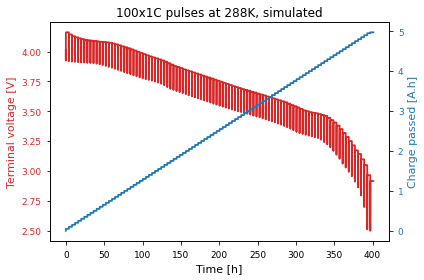

In [7]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Time [h]')
ax1.set_ylabel('Terminal voltage [V]', color=color)
ax1.set_title('100x1C pulses at 288K, simulated')
ax1.plot(t, V, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Charge passed [A.h]', color=color)  # we already handled the x-label with ax1
ax2.plot(t, Q, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.savefig('/mnt/c/Users/sok18/Desktop/pybamm_data/GITT_1C_288K.pdf')
plt.show()

In [15]:
# import experimental GITT data from file
GITT_data = pd.read_csv(
    "/mnt/c/Users/sok18/Desktop/pybamm_data/GITT_15deg_Niall.csv", comment="#", header=None
).to_numpy()
t_exp = GITT_data[:,0]/3600
I_exp = -GITT_data[:,1]/1000
V_exp = GITT_data[:,2]
Q_exp = []
for i in range (len(t_exp)):
    Q_temp = np.trapz(I_exp[0:i],t_exp[0:i])
    Q_exp.append(Q_temp)

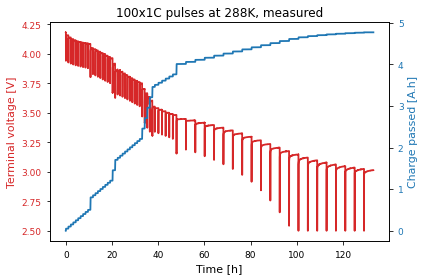

In [16]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Time [h]')
ax1.set_ylabel('Terminal voltage [V]', color=color)
ax1.set_title('100x1C pulses at 288K, measured')
ax1.plot(t_exp, V_exp, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Charge passed [A.h]', color=color)  # we already handled the x-label with ax1
ax2.plot(t_exp, Q_exp, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.savefig('/mnt/c/Users/sok18/Desktop/pybamm_data/GITT_1C_288K_exp.pdf')
plt.show()